In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from utils import *

In [4]:
def solver_name_to_precision(name):
    preconditioner_prec = name.split(".")[1].split(",")[0]
    if "Inv(torch." not in name:
        return preconditioner_prec
    else:
        inv_prec = name.split("Inv(torch.")[1].split(")")[0]
        return f"{preconditioner_prec}+{inv_prec}"


def solver_name_to_preconditioner(name):
    if "CG" in name:
        name = name.split("CG(")[1]
    return name.split("(")[0]

In [5]:
def generate_summary(df: pd.DataFrame):
    if "solve times" not in df.columns:
        return pd.DataFrame()

    df = df.copy()
    metadata_df = df.apply(extract_row_metadata, axis=1)
    metadata_cols = metadata_df.columns.tolist()
    df = pd.concat([df, metadata_df], axis=1)

    df["precision"] = df["solver"].apply(solver_name_to_precision)
    df["preconditioner"] = df["solver"].apply(solver_name_to_preconditioner)
    df["fine m"] = df["fine m"].apply(lambda x: int(x[1:]))
    df["coarse m"] = df["coarse m"].apply(lambda x: int(x[1:]))
    pivot_table = df.pivot_table(
        index=["dim", "p", "fine m", "coarse m"],
        columns=["preconditioner", "precision"],
        values=metadata_cols,
        aggfunc="min",
    )
    return pivot_table

In [6]:
df = pd.read_csv("../results/experiment_precisions.csv")
df = process_experiments_df(df)
summary = generate_summary(df)
summary

cg setup time                                   \
preconditioner        AdditiveSchwarz                                    
precision                     float32 float32+bfloat16 float32+float16   
dim p fine m coarse m                                                    
2D  1 10     8            2619.360840      2489.443848     2389.468994   
             9            3134.333496      3307.590332     3357.457031   
             10           6320.067871      6413.808594     5752.701172   
    3 9      7            2443.519043      2448.431885     2431.901611   
             8            2940.295166      2794.745605     2755.113525   
             9            3426.075439      3679.740967     3400.308594   
    5 8      6            2576.687988      2680.951660     2594.001465   
             7            2659.237549      2723.991699     2567.626709   
             8            2976.353027      4371.408203     3633.102051   
3D  1 6      4            3102.811279      2930.323486     2968.459961   
             5            3393.028564      3388.068604     3259.961914   
             6            7890.136230      7865.409180     7793.691406   
    2 5      3            3403.444092      3819.728516     3132.878174   
             4            2784.924561      3370.109131     2961.488525   
             5            3487.173096      3529.349609     3648.069092   
    3 4      2            2788.184570      3038.206299     2729.788330   
             3            2686.286377      2499.530273     2632.178223   
             4            2620.404785      2618.614258     2626.171387   

                                                                     \
preconditioner                                                        
precision                  float64 float64+bfloat16 float64+float16   
dim p fine m coarse m                                                 
2D  1 10     8         3041.159424      2513.013916     2321.604248   
             9         3010.464111      3208.672852     3136.125732   
             10        5978.264648      5564.819336     6011.601562   
    3 9      7         2442.449707      2614.135986     2351.563965   
             8         2848.540039      2705.838623     2715.214844   
             9         3585.604492      3849.431885     3529.319580   
    5 8      6         2708.712158      2815.067871     2726.154297   
             7         2624.041260      2731.006836     2648.354736   
             8         2963.015625      2998.303711     2910.284912   
3D  1 6      4         3217.747314      3124.123291     3190.476807   
             5         3399.240967      3409.153076     3335.694580   
             6         8196.600586      8001.713379     9008.847656   
    2 5      3         4402.080566      3620.199707     3592.372559   
             4         2647.639404      2987.414062     2971.921875   
             5         3775.780273      4313.116699     3679.365479   
    3 4      2         3227.345215      2822.501465     2891.895264   
             3         2742.810303      2937.649414     2573.409180   
             4         2760.417969      2682.125977     2607.091553   

                                                                      \
preconditioner                        HybridSchwarz                    
precision             float64+float32       float64 float64+bfloat16   
dim p fine m coarse m                                                  
2D  1 10     8            2302.732910   2659.003418      2415.175781   
             9            3222.334961   3410.953857      3231.197754   
             10           5973.372070   5891.059570      6136.168945   
    3 9      7            2414.573975   2809.555664      2922.234863   
             8            2793.557861   3145.791016      3204.864746   
             9            3538.534424   3738.624756      3866.188965   
    5 8      6            2799.846436   2958.398926      3039.201172   
             7            2644.934082   

In [7]:
def shorten_precision(prec):
    return "+".join(
        [("fp" if p.startswith("f") else "bf") + p[-2:] for p in prec.split("+")]
    )

## Sanity check

In [8]:
experiments = summary.index.droplevel("coarse m").unique().to_list()
experiments

[('2D', 1, 10),
 ('2D', 3, 9),
 ('2D', 5, 8),
 ('3D', 1, 6),
 ('3D', 2, 5),
 ('3D', 3, 4)]

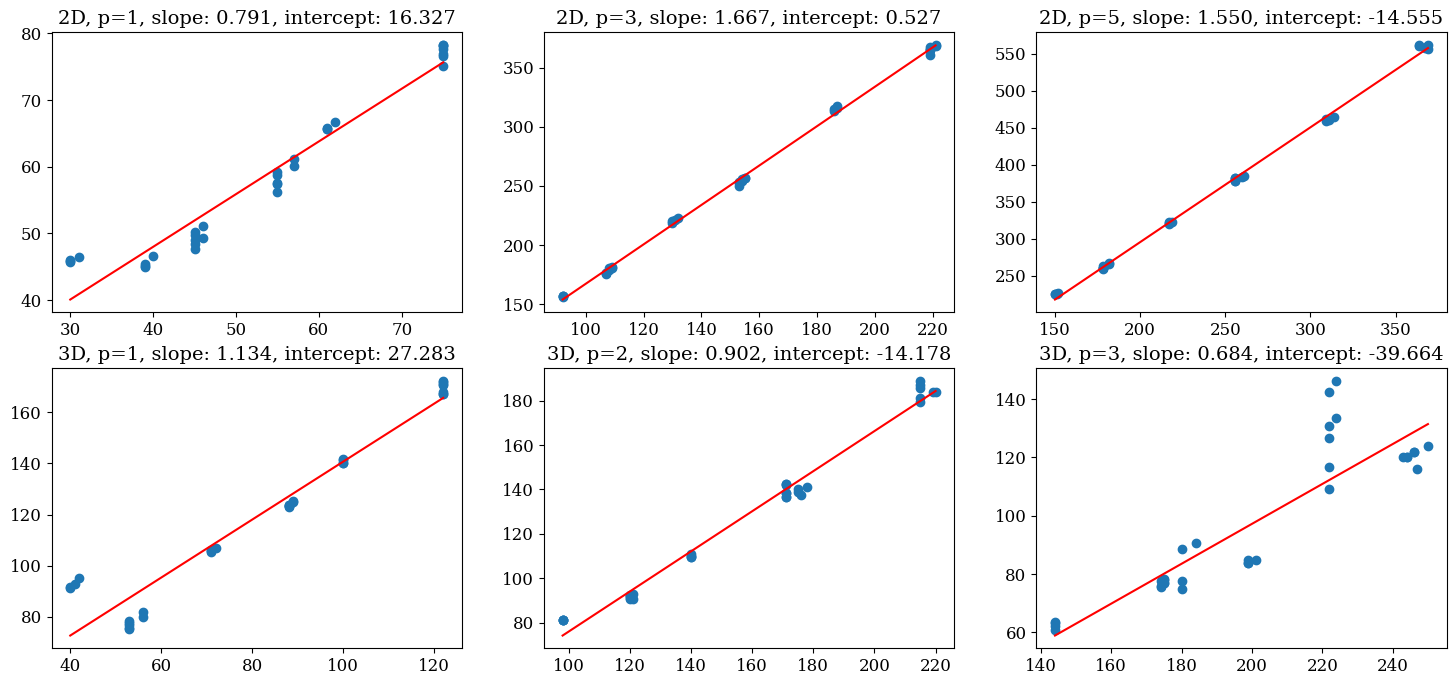

In [9]:
from sklearn.linear_model import LinearRegression

ncols = 3
nrows = (len(experiments) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
for i, (dim, p, fine_m) in enumerate(experiments):
    ax = axes.flatten()[i]

    sp = summary.xs(dim, level="dim").xs(p, level="p").xs(fine_m, level="fine m")
    iters = sp["iterations"].values.flatten()
    cg_time = (
        sp["cg time"] - sp["preconditioner time"] * sp["iterations"]
    ).values.flatten()
    cg_time = cg_time[~np.isnan(cg_time)]
    cg_time = cg_time[iters < 600]
    iters = iters[iters < 600]
    ax.scatter(iters, cg_time)

    model = LinearRegression().fit(iters.reshape(-1, 1), cg_time)
    ax.set_title(
        f"{dim}, p={p}, slope: {model.coef_[0]:.3f}, intercept: {model.intercept_:.3f}"
    )

    itx = np.linspace(iters.min(), iters.max(), 100).reshape(-1, 1)
    predicted = model.predict(itx)
    ax.plot(itx, predicted, color="red", label="Linear fit")

## Iteration count table

In [10]:
nice_col_names = {
    "p": "$p$",
    "fine m": "$m$",
    "solvers m": "$M$",
    "coarse m": "$\\mathcal{M}$",
}

precisions_order = [
    "float64",
    "float64+float32",
    "float64+float16",
    "float64+bfloat16",
    "float32",
    "float32+float16",
    "float32+bfloat16",
]

iter_summary = summary["iterations"].copy()

iter_summary = iter_summary.reindex(
    columns=pd.Index(
        iter_summary.columns.levels[1],
        name="precision",
    ).reindex(
        precisions_order
    )[0],
    level="precision",
)

formatted_iter_table = iter_summary.astype(int).style.format_index(
    lambda prec: f"{{\\texttt{{{shorten_precision(prec)}}}}}",
    axis=1,
    level="precision",
)
formatted_iter_table.index.rename(nice_col_names, inplace=True)
formatted_iter_table.columns.name = None


def highlight_values(s):
    return (
        [""]
        + [
            "color: #ff0000;" if v > 500 else "color: #aaaaaa" if v == s.iloc[0] else ""
            for v in s[1:7]
        ]
        + [""]
        + [
            "color: #ff0000;" if v > 400 else "color: #aaaaaa" if v == s.iloc[7] else ""
            for v in s[8:]
        ]
    )


formatted_iter_table = formatted_iter_table.apply(highlight_values, axis=1)

formatted_iter_table

In [11]:
iter_table_latex = formatted_iter_table.to_latex(
    hrules=True,
    multirow_align="t",
    column_format="rrrr|"
    + 7 * "S[table-format=3, table-column-width=2em]"
    + "|"
    + 4 * "S[table-format=3, table-column-width=2em]",
    convert_css=True,
)
latex_lines = iter_table_latex.split("\n")
first_header_line = latex_lines.index("\\toprule") + 1
last_header_line = latex_lines.index("\\midrule") - 1
column_names = [None] * len(latex_lines[first_header_line + 1].split("&"))
for line in latex_lines[first_header_line + 1 : last_header_line + 1]:
    line_col_names = [x.strip().removesuffix("\\\\") for x in line.split("&")]
    for i, col_name in enumerate(line_col_names):
        if col_name:
            column_names[i] = col_name
single_header_line = " & ".join(column_names) + " \\\\"
hacked_pivot_latex = "\n".join(
    latex_lines[:first_header_line]
    + [single_header_line]
    + latex_lines[last_header_line + 1 :]
)
with open("../docs/tables/experiment_precision_iterations.tex", "w") as f:
    f.write(hacked_pivot_latex)

## Plots

In [12]:
def get_plot_df(dim, p, precision, preconditioner):
    data = (
        summary.xs(p, level="p")
        .xs(dim, level="dim")
        .xs(precision, level="precision", axis=1)
        .xs(preconditioner, level="preconditioner", axis=1)
        .reset_index()
        .set_index("coarse m")
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    # total_preconditioner_rest = "$R_C$, $R_C^T$, type casts"
    total_preconditioner_rest = "other preconditioner components"
    total_not_preconditioner = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_preconditioner_rest] = (
        data["preconditioner time"]
        - data["local solvers time"]
        - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_preconditioner] = (
        data["cg time"]
        - data[total_preconditioner_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[
            [
                total_not_preconditioner,
                total_preconditioner_rest,
                total_coarse_solver,
                total_local_solvers,
            ]
        ]
        / 1000
    )
    return to_plot

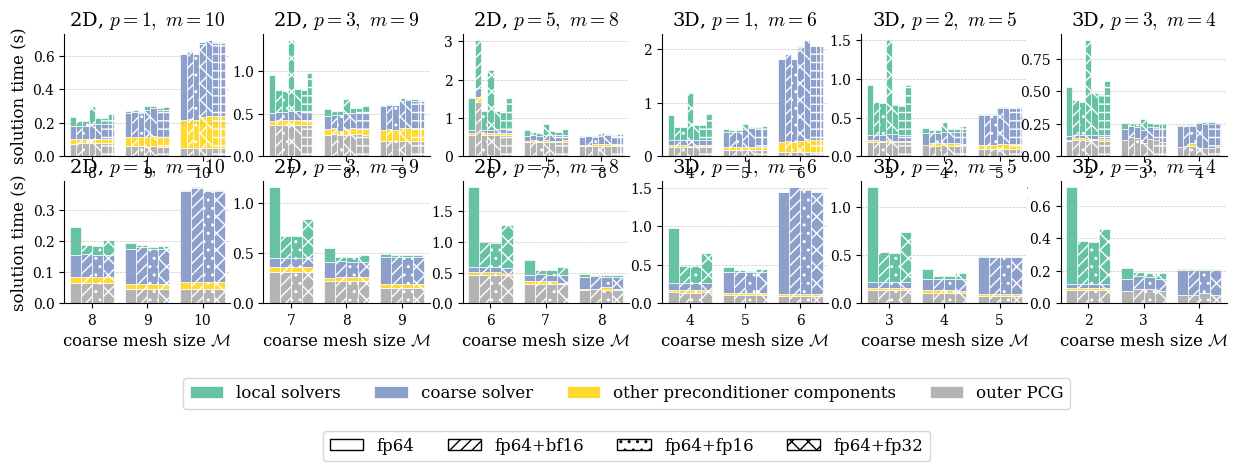

In [13]:
fig, axes = plt.subplots(2, len(experiments), figsize=(15, 3.5))
hatch_list = ["", "///", "..", "xx", "\\\\", "--", "++"]
for i, preconditioner in enumerate(("AdditiveSchwarz", "HybridSchwarz")):
    precisions = summary.columns.levels[2].to_list()
    prec_prec = set(summary["iterations"].columns.to_list())
    precisions = [prec for prec in precisions if (preconditioner, prec) in prec_prec]

    for j, (dim, p, fine_m) in enumerate(experiments):
        ax = axes[i, j]

        plot_clustered_stacked(
            ax,
            [
                get_plot_df(dim, p, precision, preconditioner)
                for precision in precisions
            ],
            precisions,
            hatch_list=hatch_list,
            add_legend=False,
        )
        m = (
            summary.xs(dim, level="dim")
            .xs(p, level="p")
            .index.get_level_values("fine m")[0]
        )
        ax.set_title(f"{dim}, $p={p},\\ m={m}$")
        ax.set_xlabel("coarse mesh size $\\mathcal{M}$")
        if j == 0:
            ax.set_ylabel("solution time (s)")
        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.tick_params(axis="both", which="minor", labelsize=8)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncols=4,
)

proxies = []
for i, prec in enumerate(precisions):
    p = mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatch_list[i] or "",
        # alpha=alpha_list[i],
        label=prec,
    )
    proxies.append(p)
fig.legend(
    proxies,
    map(shorten_precision, precisions),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.23),
    ncols=4,
)
# fig.savefig("../docs/thesis-media/precision_plots.svg", bbox_inches="tight")

## Bf16 convergence history

ValueError: malformed node or string: {'iterations': 364, 'residual norms': [0.23042262653948303, 6.781305266349707, 3.924664045616056, 15.931959465407775, 7.6849451993131686, 12.679384551589527, 7.596436111259394, 8.93363308951702, 11.357617135518318, 10.253725431726481, 9.441889162196805, 12.980451424542492, 7.617927266331789, 10.550395065663468, 10.655953491577518, 8.073322777847299, 8.74353734035538, 9.093266535125627, 7.301009559523008, 7.499010652500555, 6.841092046282437, 6.241139086256857, 6.141753052377688, 4.628111449386556, 5.3906764772988565, 3.641227758869321, 4.604756332092852, 3.2600806390330765, 2.879302665985108, 2.5944437400838796, 2.939630037434309, 2.2772691024464615, 1.7350748236616218, 2.121962082891154, 1.6543796667744273, 1.3943397375252646, 1.654015951026724, 1.621401512340867, 1.0978290732458107, 1.0601636277604427, 1.027955797986041, 0.8325054285825201, 0.929851370794355, 0.8898866151302963, 0.6458634587905303, 0.5438214174694067, 0.4974292637232956, 0.481540

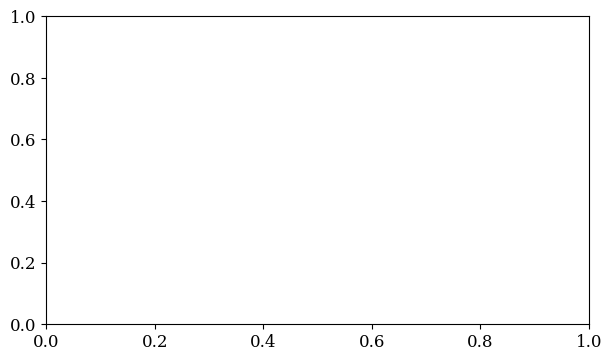

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

df_prec = df.apply(lambda row: solver_name_to_precision(row["solver"]), axis=1)
line_styles = ["-", "--", ":", "-"]
for i, prec in enumerate(precisions):
    res_norms = ast.literal_eval(
        df[
            (df["p"] == 5)
            & (df["coarse m"] == "S6")
            & (df["solver"].str.contains("CG"))
            & (df_prec == prec)
        ].iloc[0]["metadata"]
    )["residual norms"]
    ax.plot(res_norms, label=shorten_precision(prec), linestyle=line_styles[i])

ax.set_yscale("log")
ax.legend(loc="upper right")
ax.set_xlabel("PCG iteration")
ax.set_ylabel("residual Euclidean norm")
fig.savefig("../docs/thesis-media/precision_residuals.svg", bbox_inches="tight")

## Numbers

In [ ]:
def get_speedup(what: str, prec: str, base="float64"):
    return summary[(what, base)] / summary[(what, prec)]

In [ ]:
get_speedup("cg time", "float32+float16", base="float32")

p  fine m  coarse m
1  10      8           1.097865
           9           1.010775
           10          0.998837
3  9       7           1.207015
           8           1.047074
           9           0.999175
5  8       6           1.279191
           7           1.101839
           8           1.018533
dtype: float64